In [1]:
import pandas as pd
df1=pd.read_csv('Datasets/house-prices-advanced-regression-techniques/train.csv')
df1.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Exploratory Data Analysis

In [2]:
df1.shape

(1460, 81)

In [3]:
df1.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [4]:
dty=df1.dtypes
print(dty.array)

<NumpyExtensionArray>
[  dtype('int64'),   dtype('int64'),       dtype('O'), dtype('float64'),
   dtype('int64'),       dtype('O'),       dtype('O'),       dtype('O'),
       dtype('O'),       dtype('O'),       dtype('O'),       dtype('O'),
       dtype('O'),       dtype('O'),       dtype('O'),       dtype('O'),
       dtype('O'),   dtype('int64'),   dtype('int64'),   dtype('int64'),
   dtype('int64'),       dtype('O'),       dtype('O'),       dtype('O'),
       dtype('O'),       dtype('O'), dtype('float64'),       dtype('O'),
       dtype('O'),       dtype('O'),       dtype('O'),       dtype('O'),
       dtype('O'),       dtype('O'),   dtype('int64'),       dtype('O'),
   dtype('int64'),   dtype('int64'),   dtype('int64'),       dtype('O'),
       dtype('O'),       dtype('O'),       dtype('O'),   dtype('int64'),
   dtype('int64'),   dtype('int64'),   dtype('int64'),   dtype('int64'),
   dtype('int64'),   dtype('int64'),   dtype('int64'),   dtype('int64'),
   dtype('int64'),       dtyp

In [17]:
def treat_na(df,col):
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col]=df[col].fillna(df[col].median())
    return df

In [6]:
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns

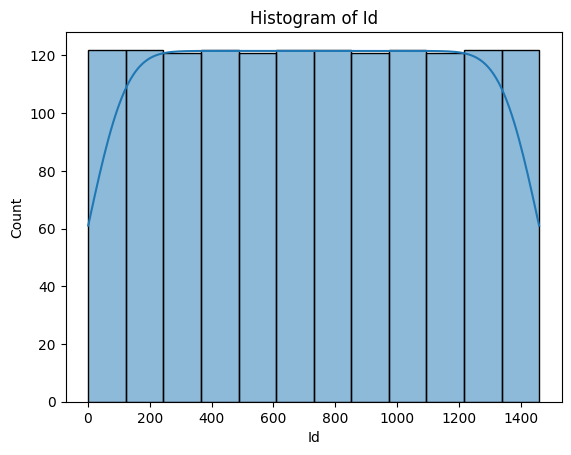

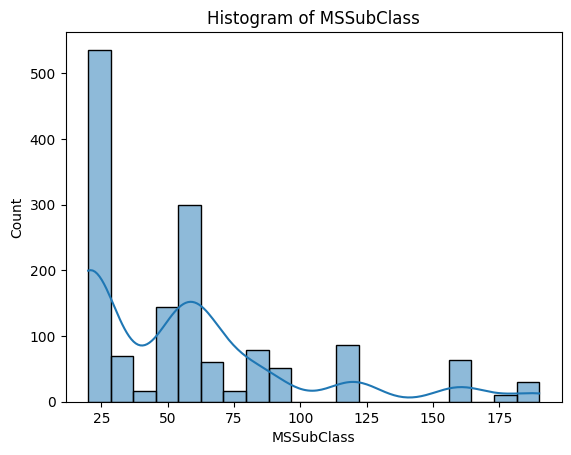

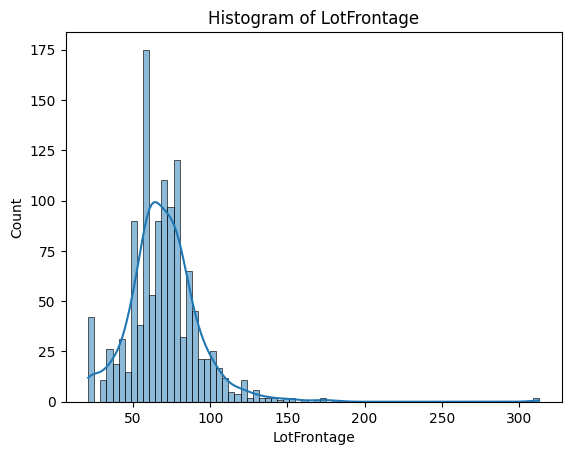

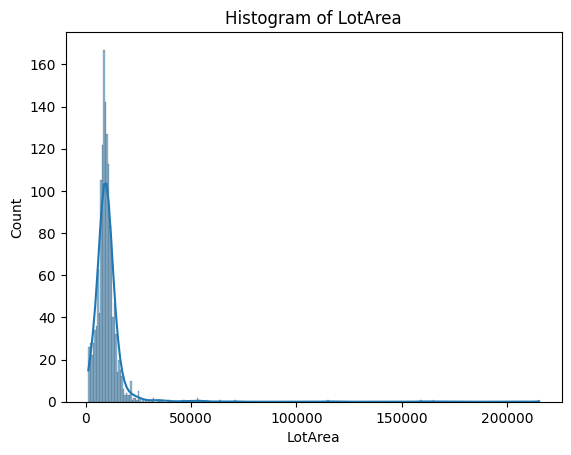

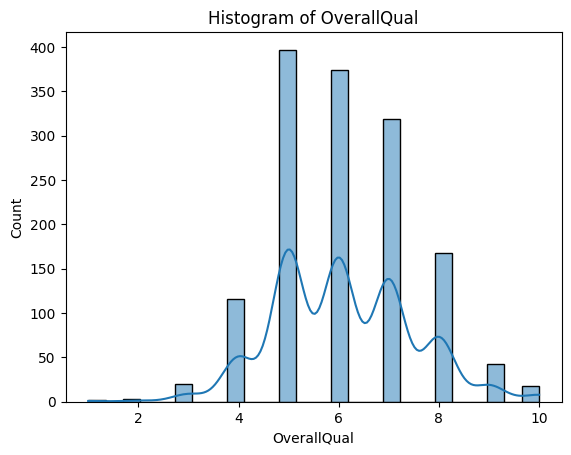

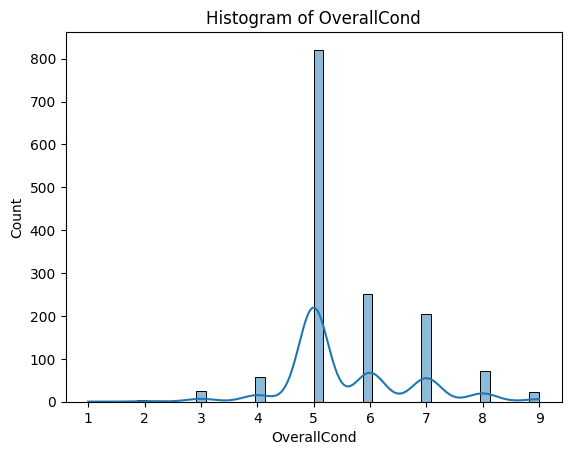

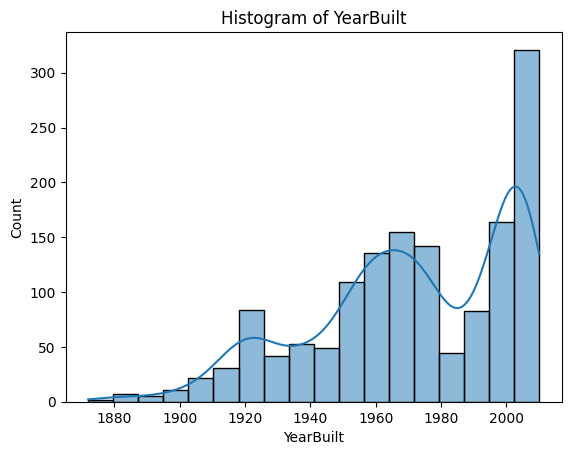

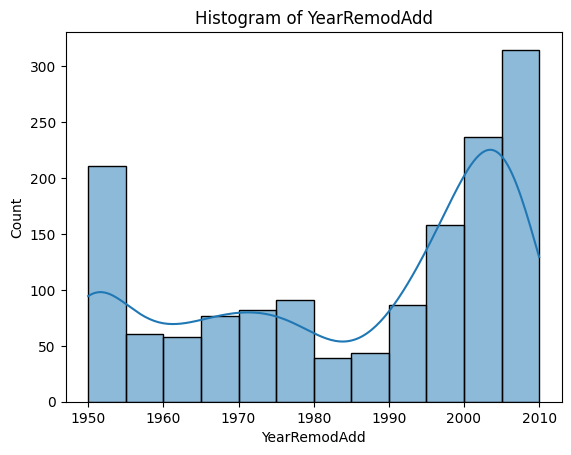

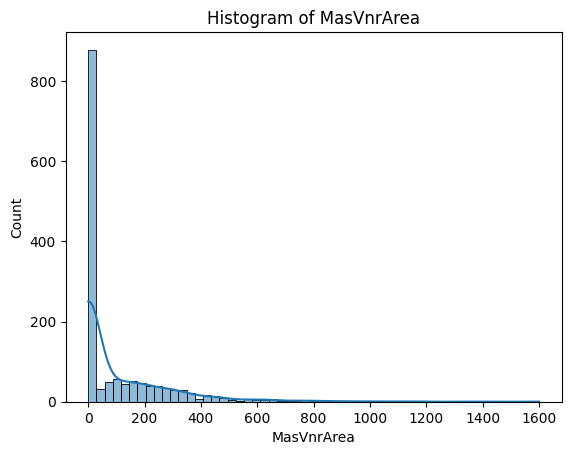

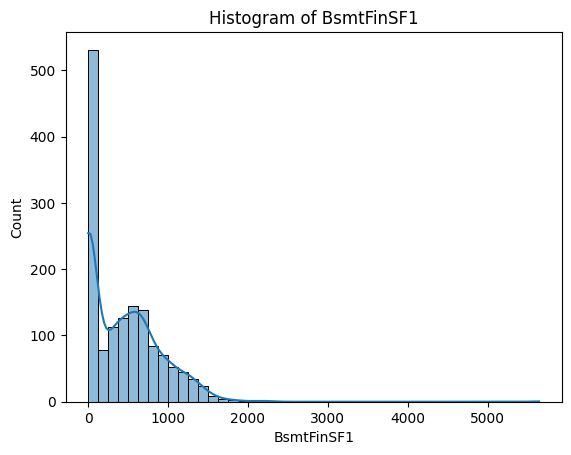

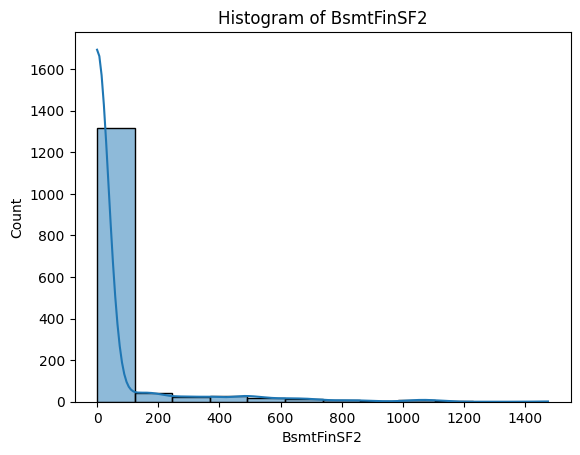

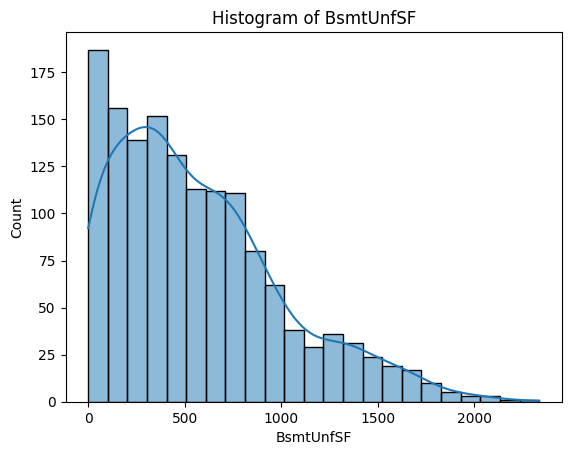

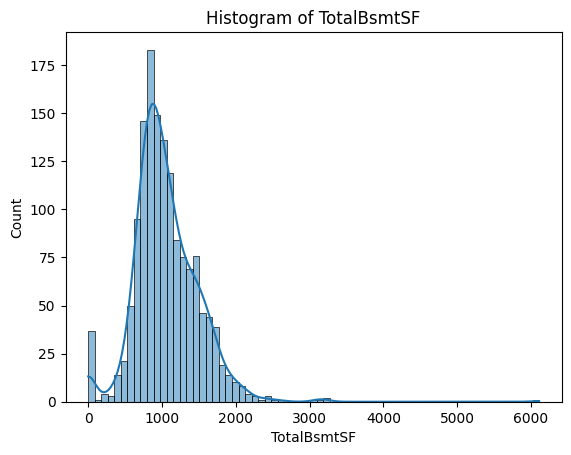

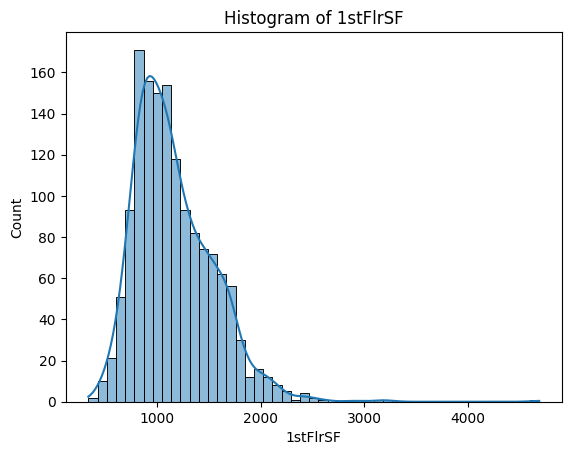

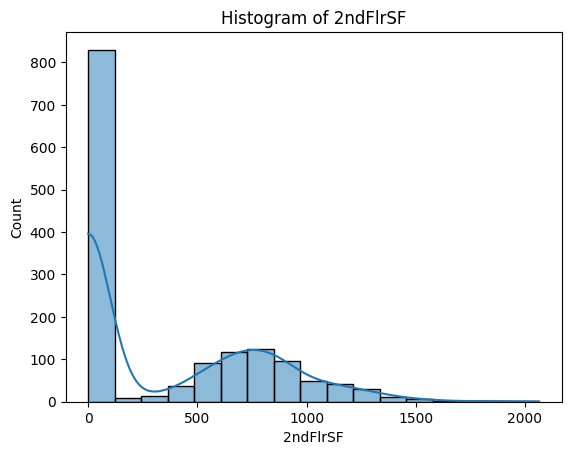

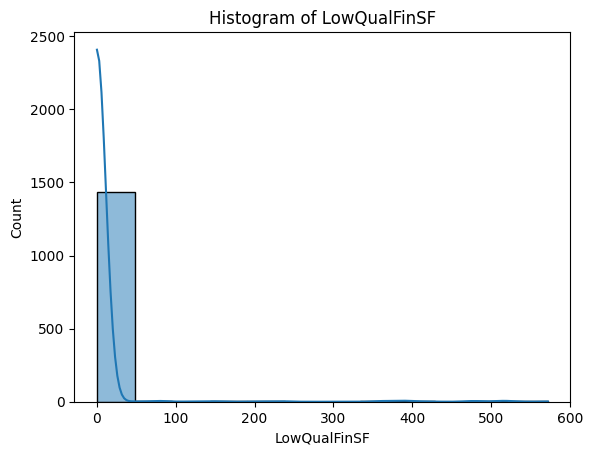

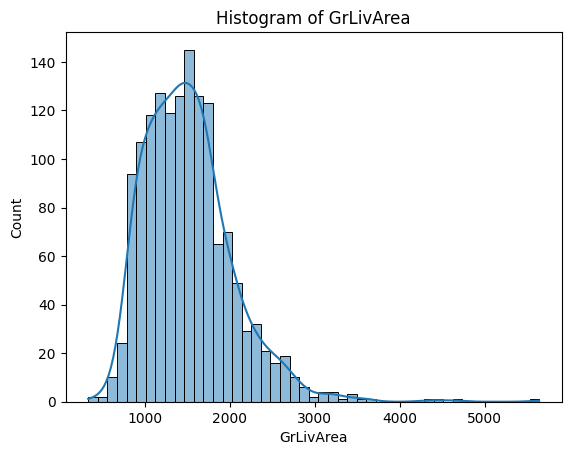

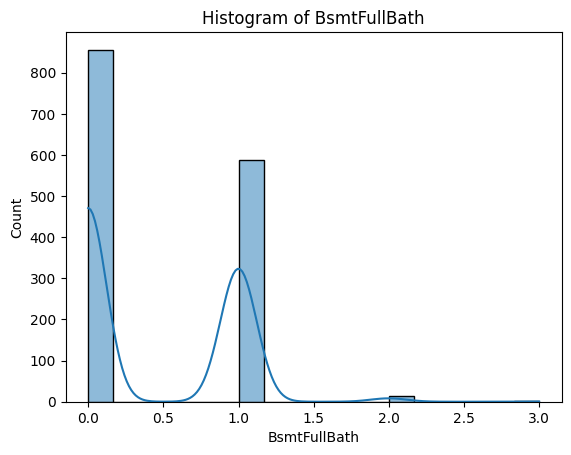

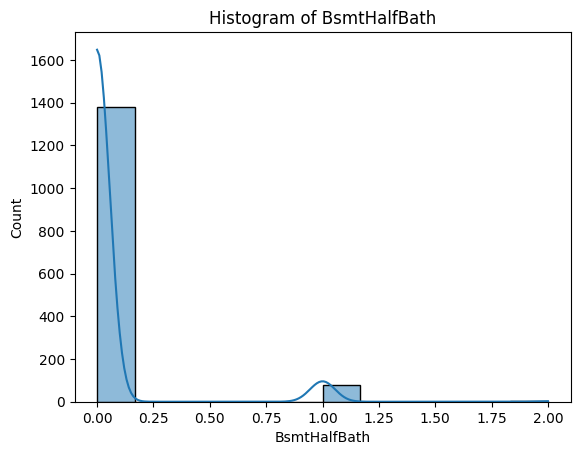

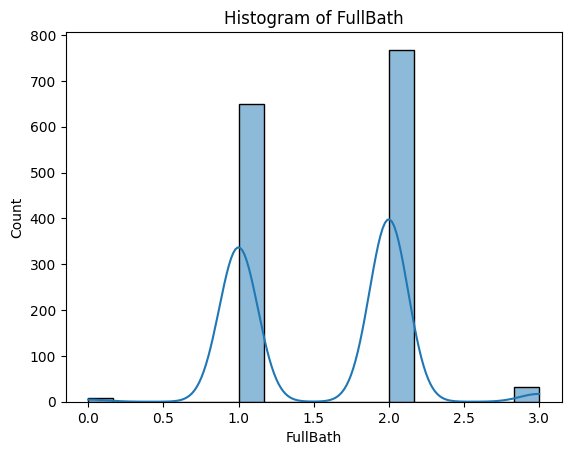

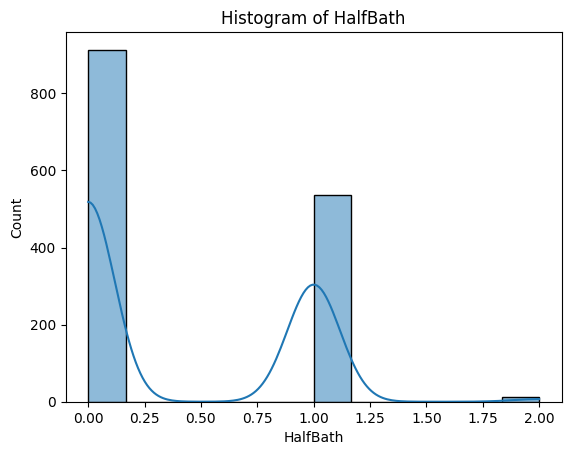

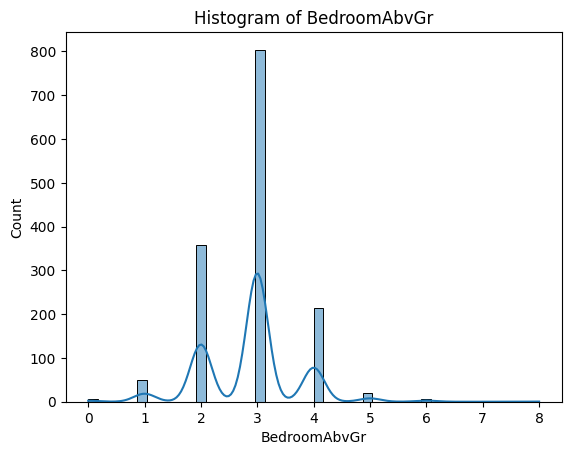

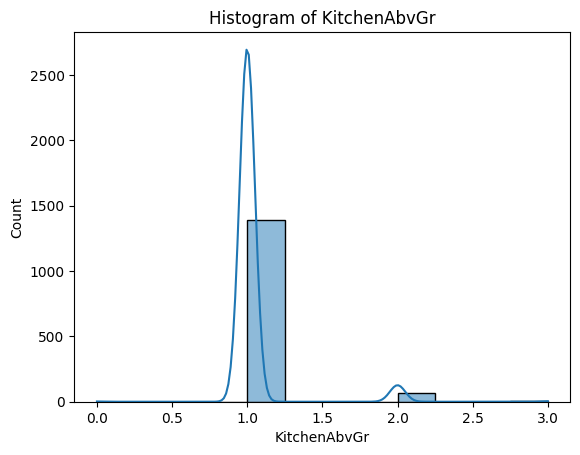

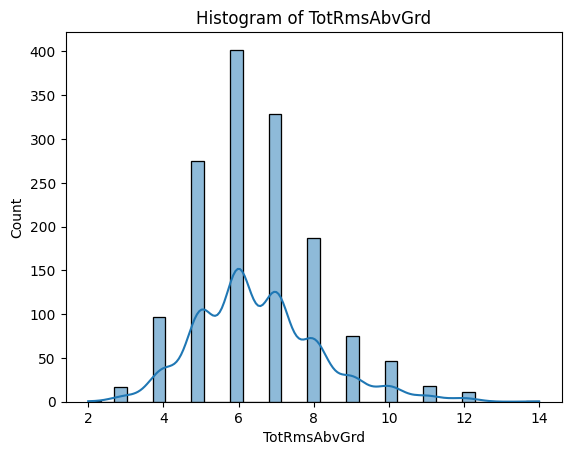

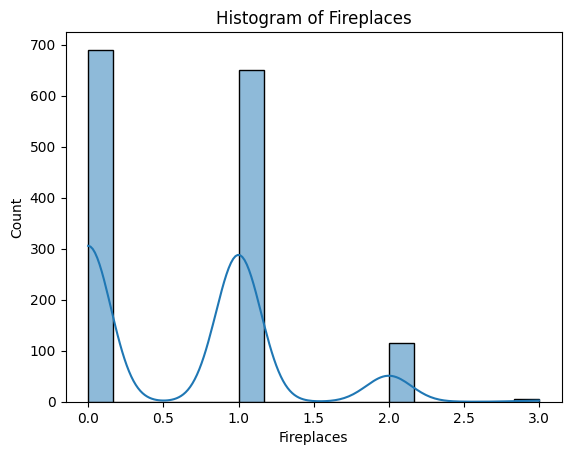

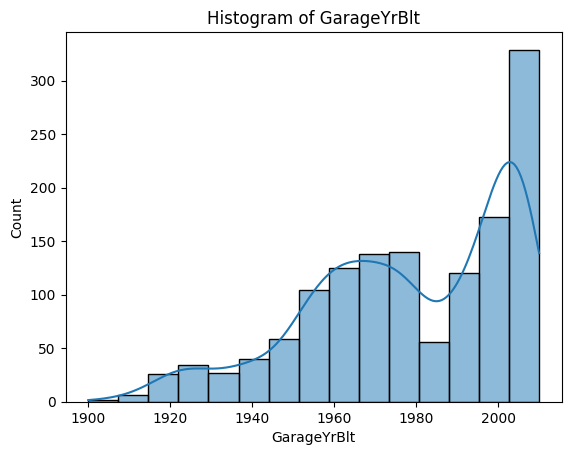

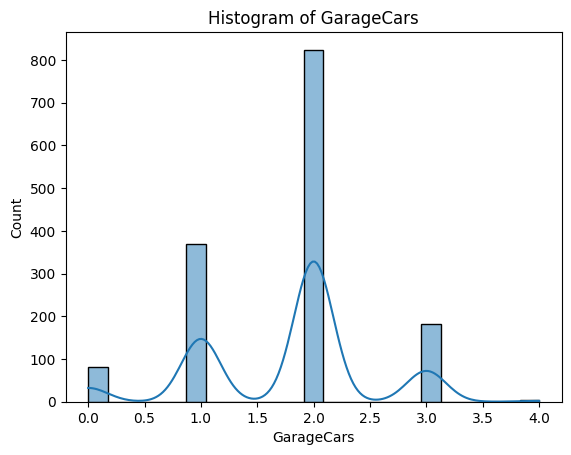

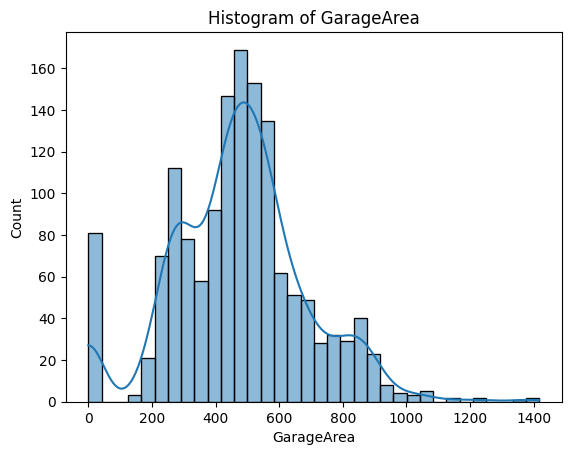

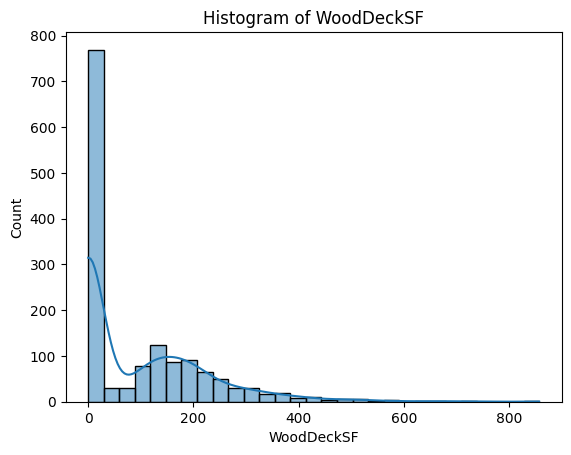

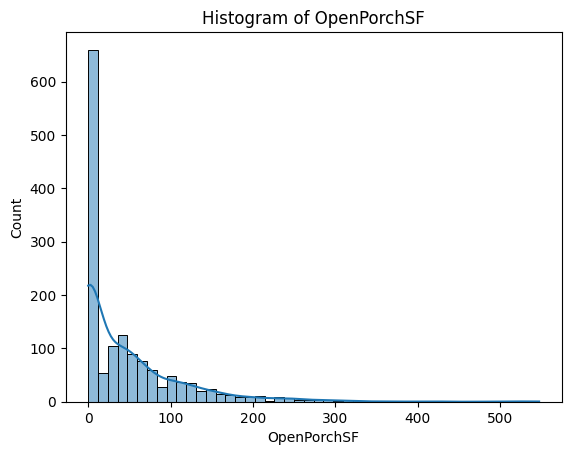

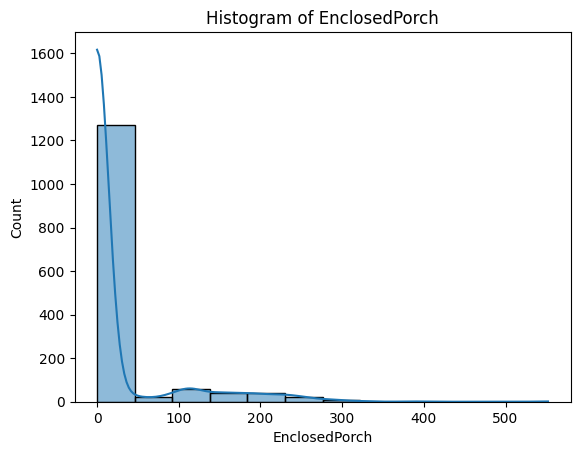

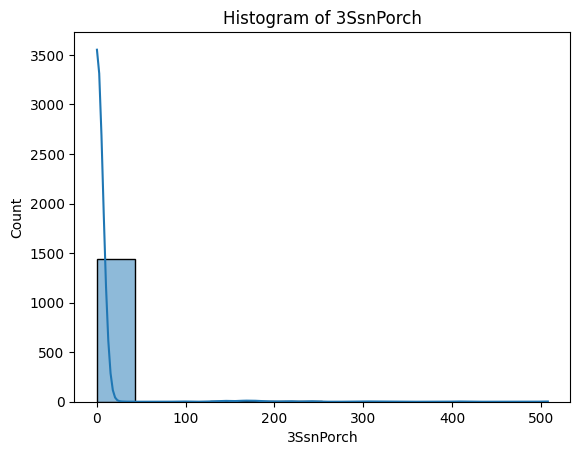

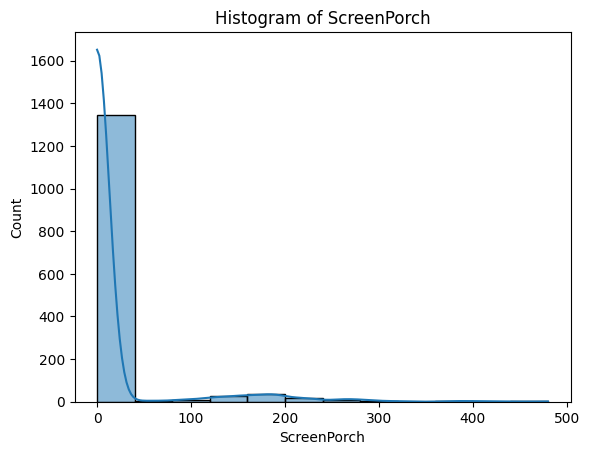

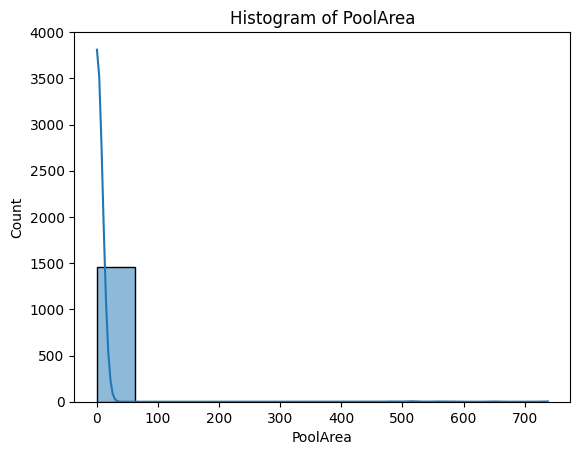

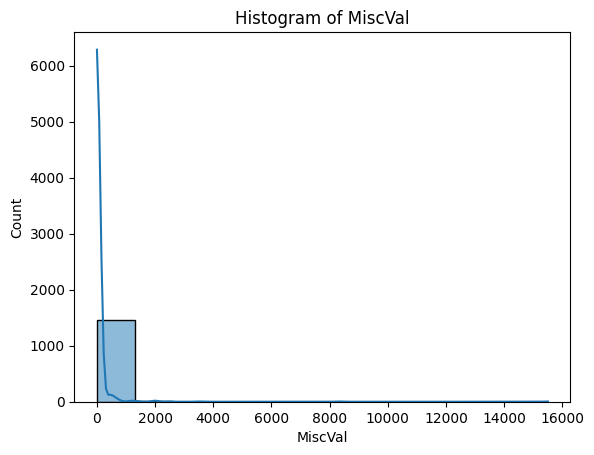

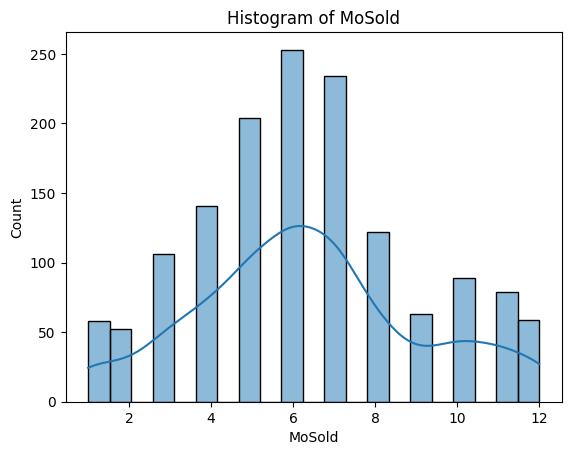

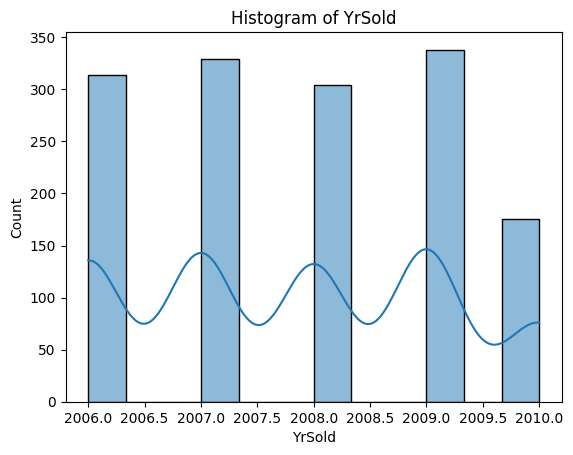

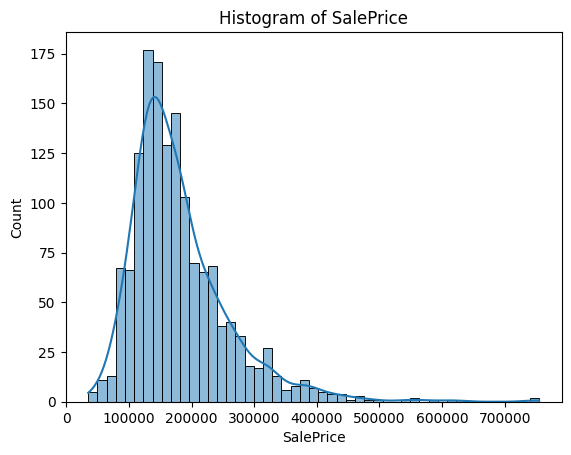

In [13]:
for col in df1.select_dtypes(include=['float','integer']).columns:
    sns.histplot(x=df1[col],kde=True)
    plt.xlabel(f'{col}')
    plt.ylabel('Count')
    plt.title(f'Histogram of {col}')
    plt.show()

In [18]:
for col in df1.columns:
    df2=treat_na(df1,col)

In [19]:
df2[[col for col in df2.columns if pd.api.types.is_integer_dtype(df2[col])]].isnull().sum()

Id               0
MSSubClass       0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

In [14]:
isnull=df1.isnull().sum()

In [15]:
isnull.where(isnull>700).dropna()

Alley          1369.0
MasVnrType      872.0
PoolQC         1453.0
Fence          1179.0
MiscFeature    1406.0
dtype: float64

In [16]:
df1.drop(columns=['Alley','PoolQC','Fence','MiscFeature','MasVnrType'],inplace=True)

In [22]:
df2.shape

(1460, 76)

In [23]:
df2.dropna(thresh=20,inplace=True)

In [24]:
df2.shape

(1460, 76)

In [25]:
isnull_obj=df2[[col for col in df2.columns if pd.api.types.is_object_dtype(df2[col])]].isnull().sum() #df2.select_dtypes(include=['object'].isnull().sum()

In [27]:
null_columns=isnull_obj.where(isnull_obj>0).dropna().index
null_columns

Index(['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond'],
      dtype='object')

In [28]:
df2[null_columns].head()

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond
0,Gd,TA,No,GLQ,Unf,SBrkr,NaN,Attchd,RFn,TA,TA
1,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA
2,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA
3,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,Unf,TA,TA
4,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,RFn,TA,TA


In [29]:
df2[null_columns].tail()
df2['FireplaceQu']=df2.apply(lambda x: x['BsmtCond'] if pd.isnull(x['FireplaceQu'])
                             else x['FireplaceQu'],axis=1)
df2.FireplaceQu.isnull().sum()

np.int64(28)

In [30]:
def treat_na_obj(df,col):
    if pd.api.types.is_object_dtype(df[col]):
        mod_val=df[col].value_counts().index[0]
        df[col]=df[col].fillna(mod_val)
    return df

In [31]:
for col in df2.columns:
    df3=treat_na_obj(df2,col)

In [32]:
df3.select_dtypes(include=['object']).isnull().sum()

MSZoning         0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinType2     0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
KitchenQual      0
Functional       0
FireplaceQu      0
GarageType       0
GarageFinish     0
GarageQual       0
GarageCond       0
PavedDrive       0
SaleType         0
SaleCondition    0
dtype: int64

## outlier removal

In [47]:
df_num=df3.select_dtypes(include=['integer','float'])

In [48]:
df_num.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


<Axes: xlabel='MasVnrArea', ylabel='Count'>

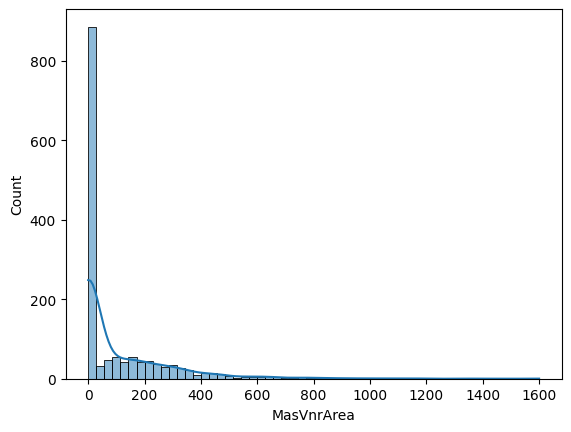

In [35]:
import seaborn as sns
sns.histplot(data=df_num,x='MasVnrArea',kde=True)

In [49]:
df_num.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [50]:
from matplotlib import pyplot as plt
def remove_outlier(df,col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    df=df[(df[col]>=q1-1.5*iqr)&(df[col]<=q3+1.5*iqr)]
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col} after outlier removal")
    plt.show()
    return df

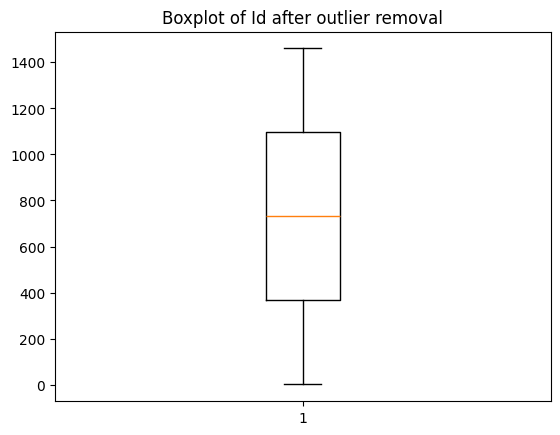

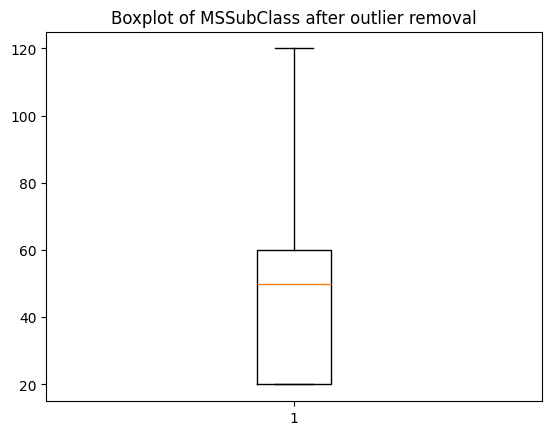

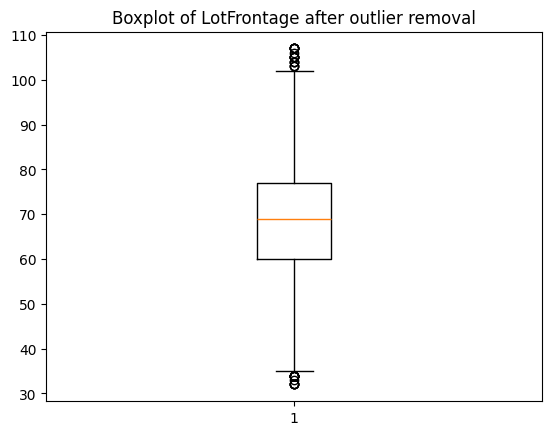

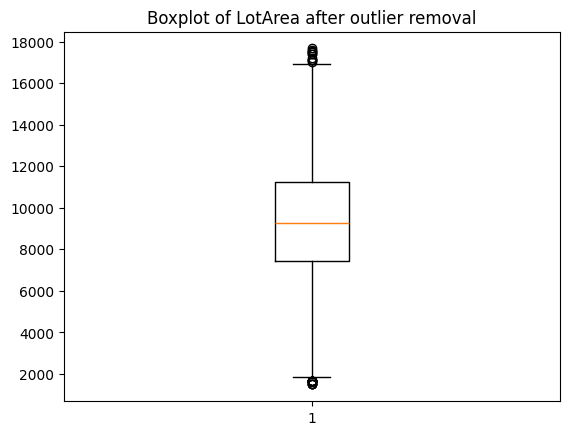

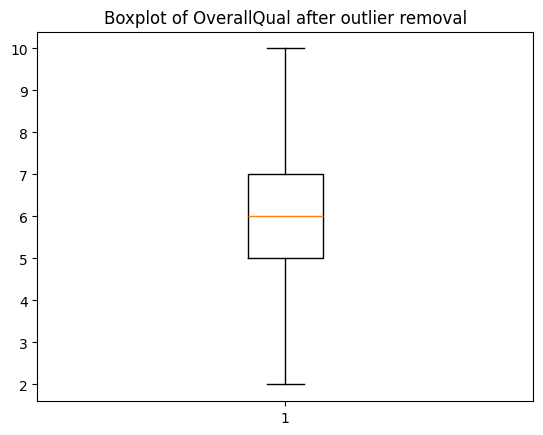

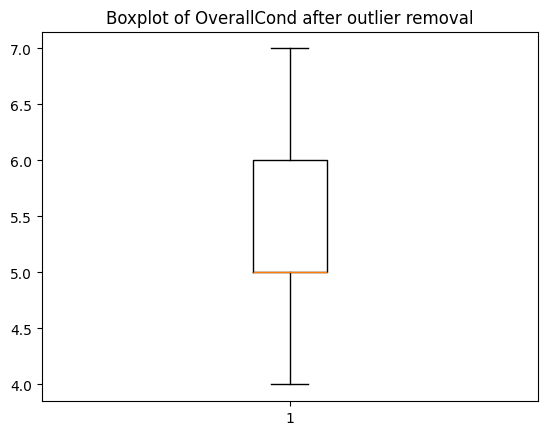

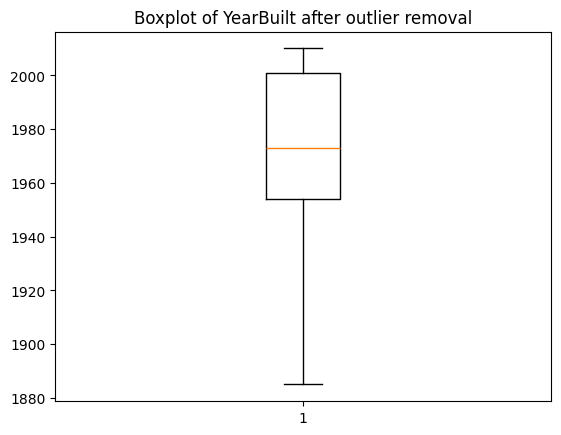

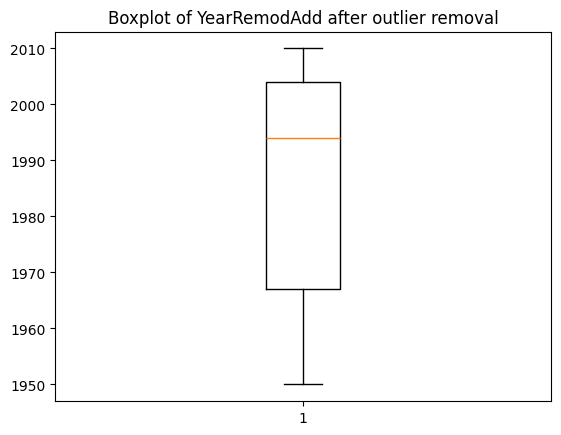

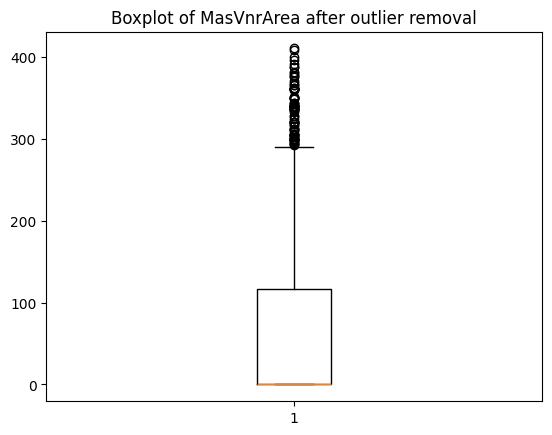

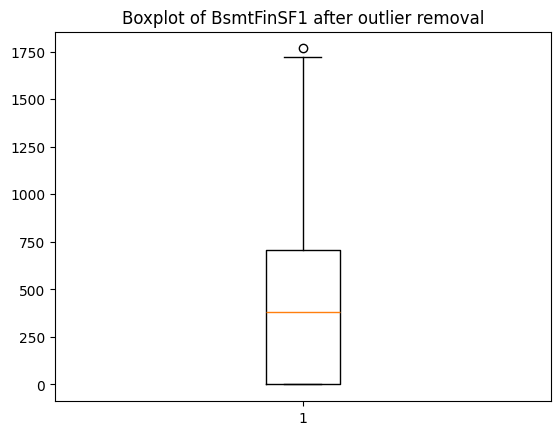

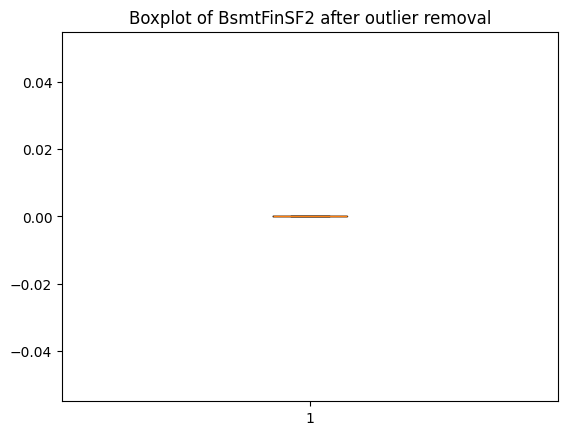

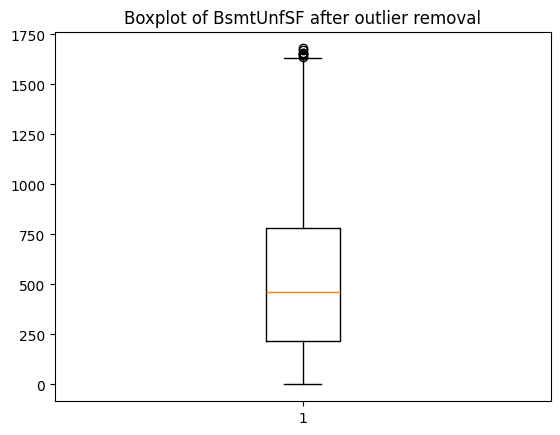

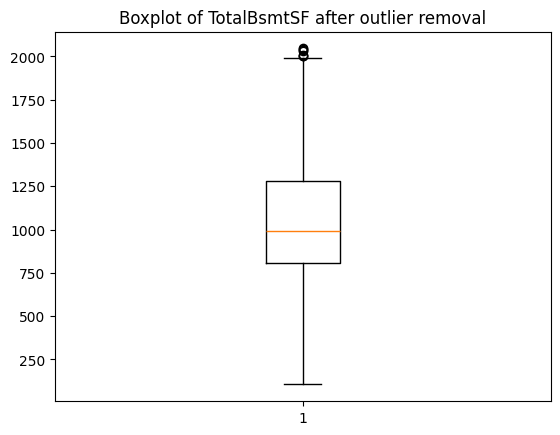

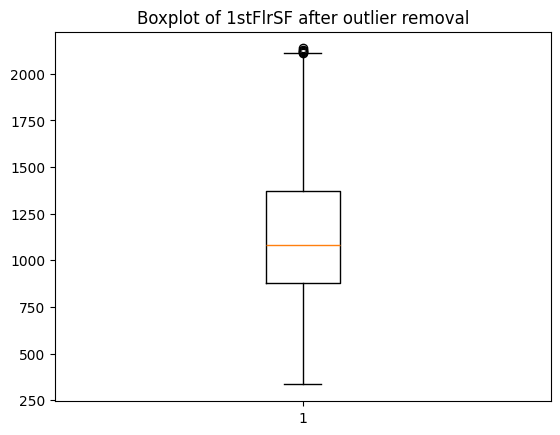

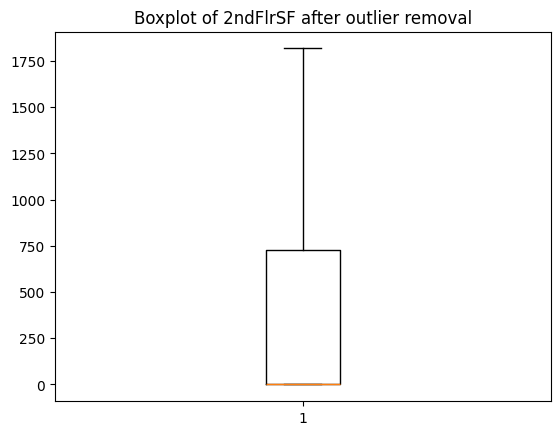

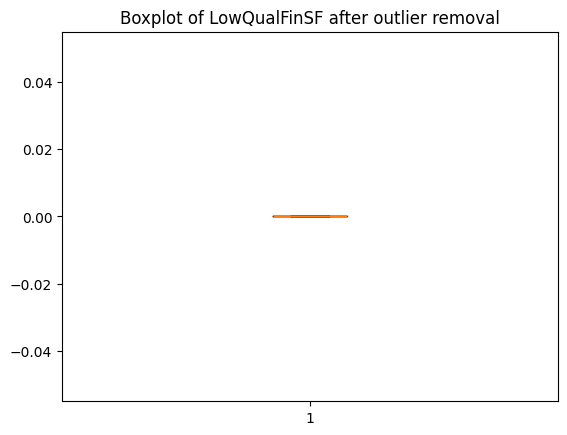

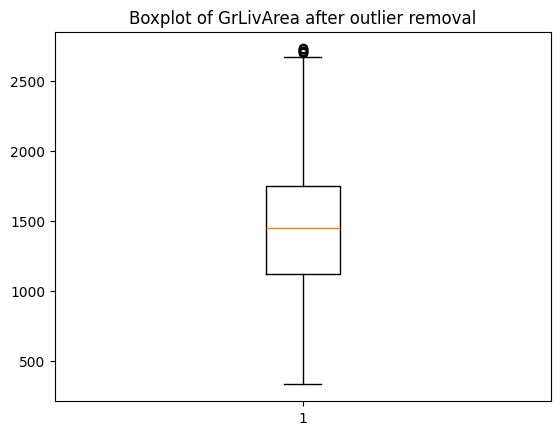

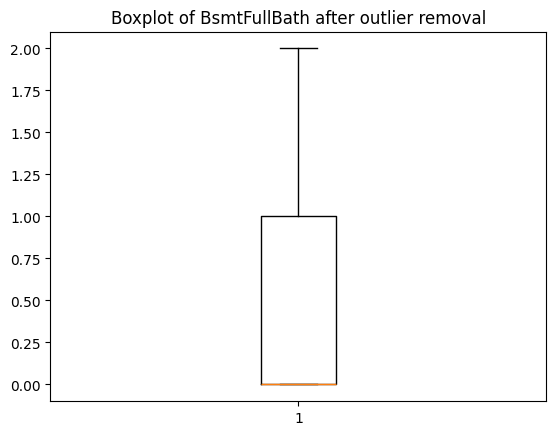

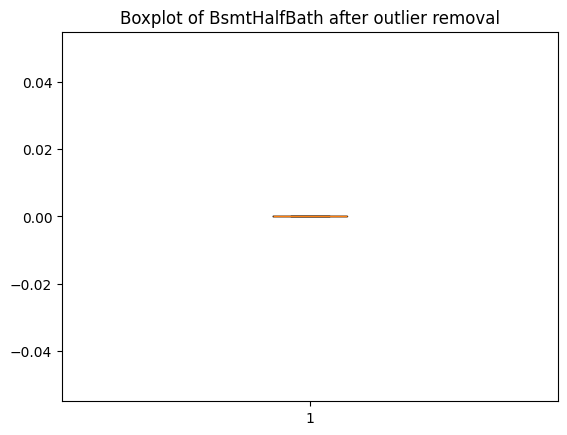

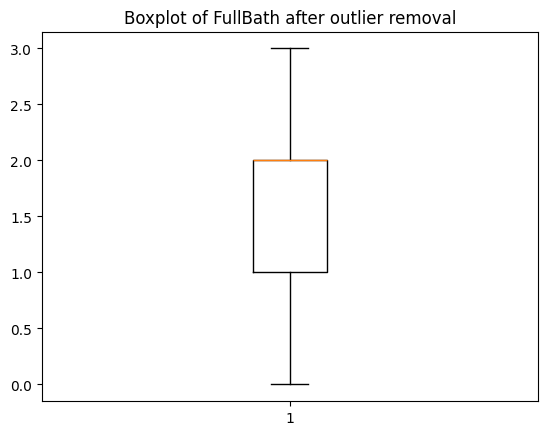

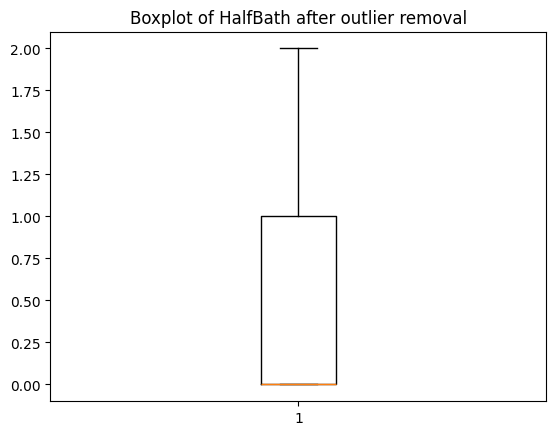

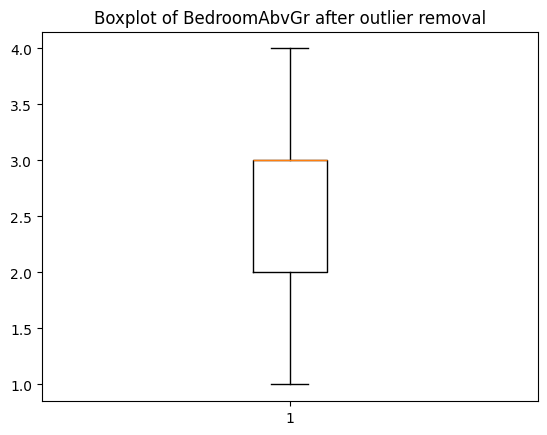

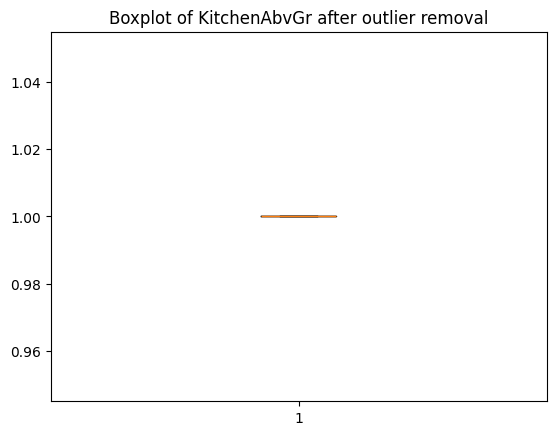

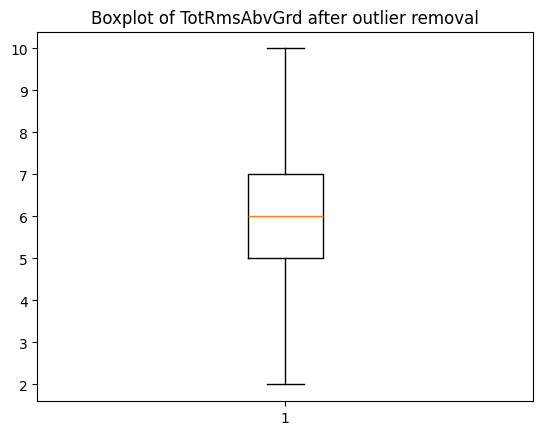

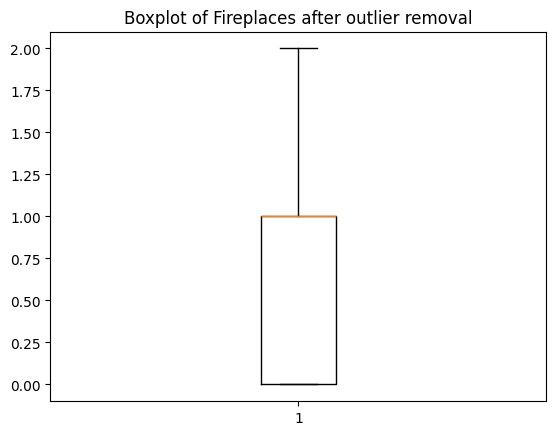

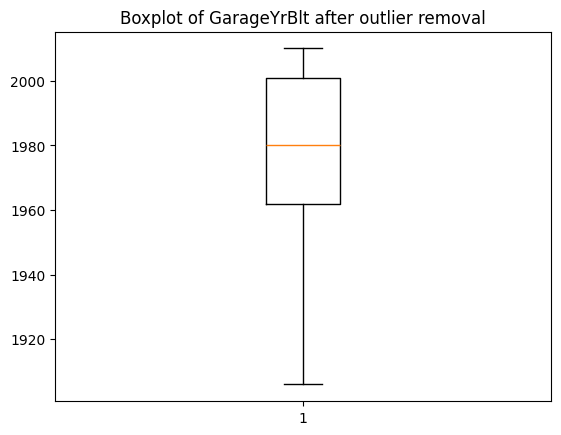

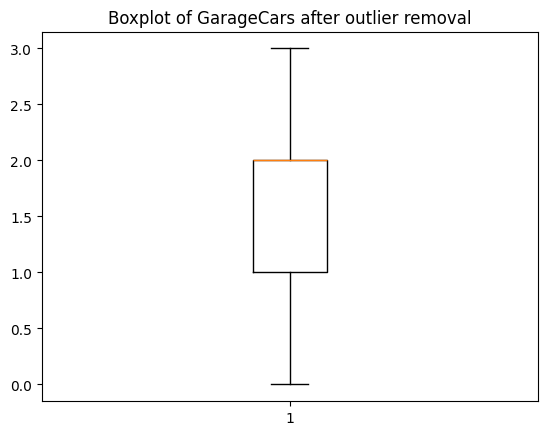

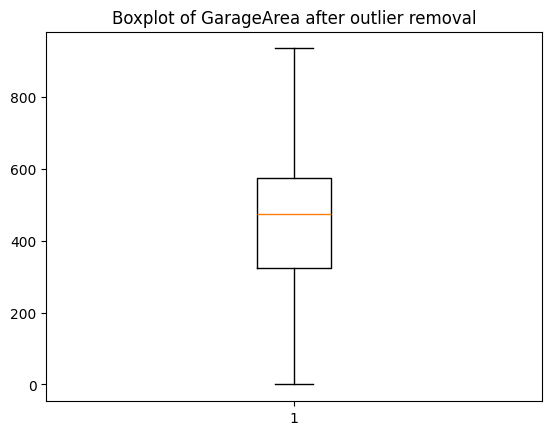

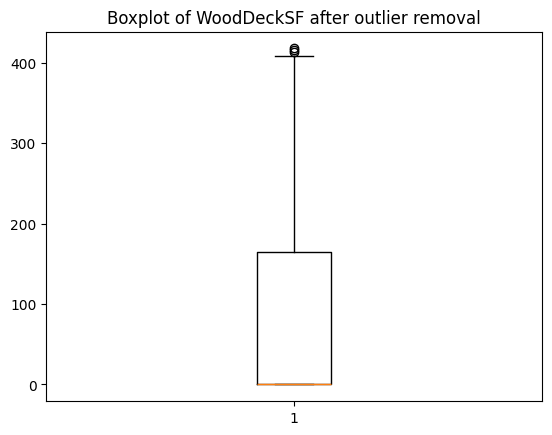

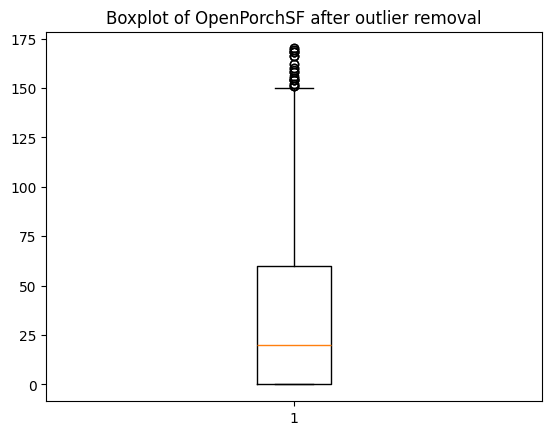

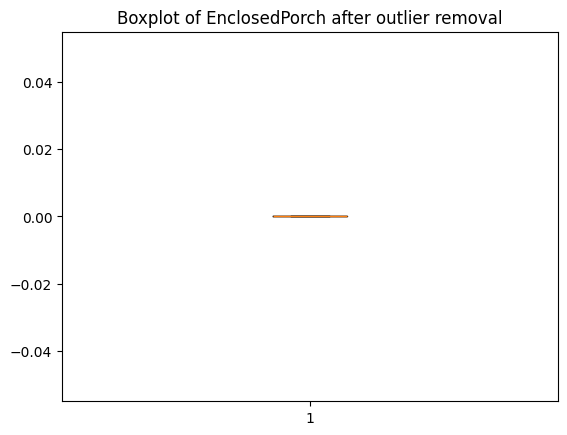

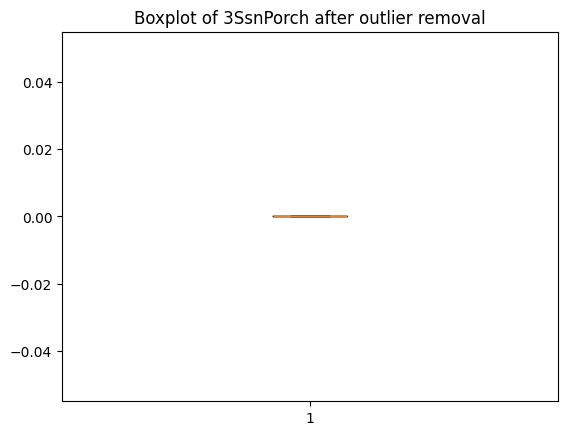

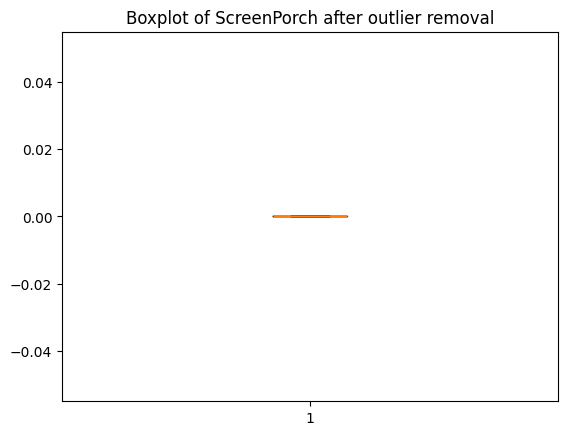

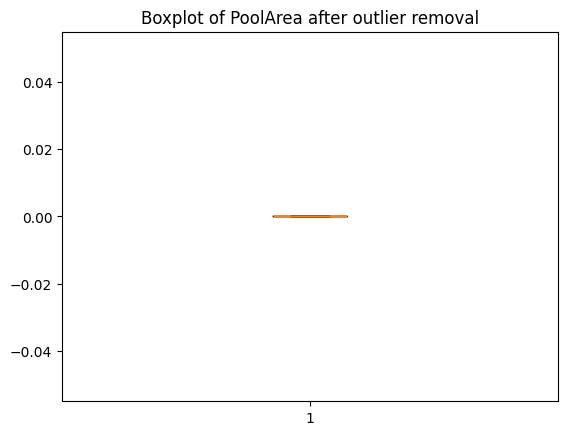

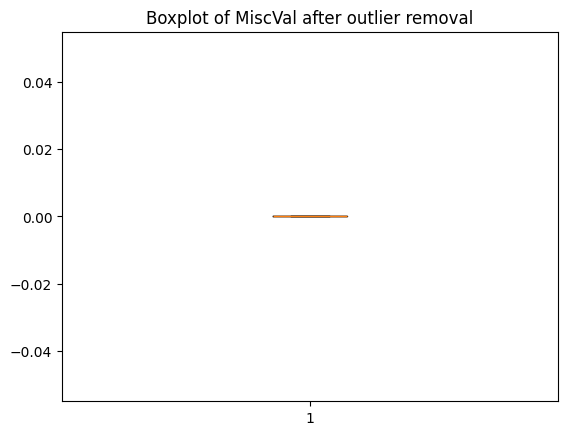

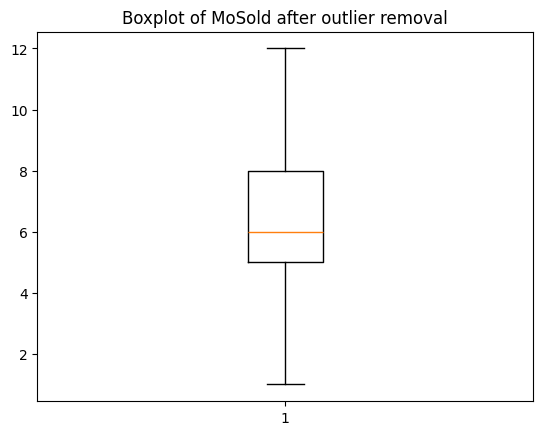

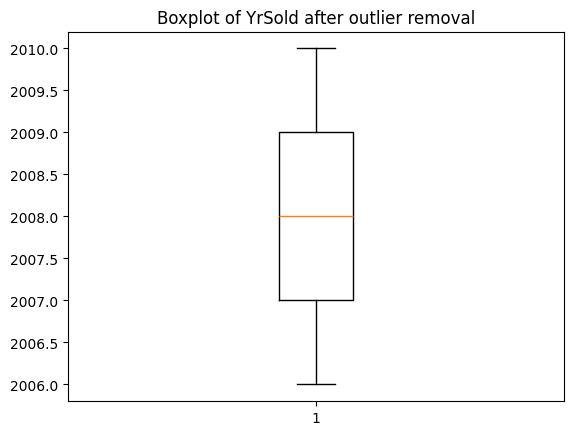

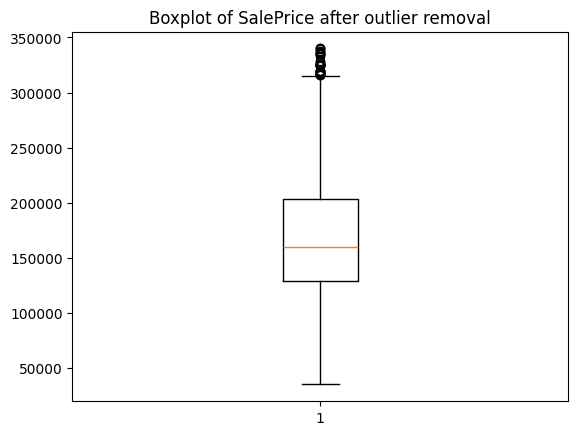

In [51]:
for col in df_num.columns:
    if col != 'SalesPrice':
        df_num1=remove_outlier(df_num,col)

In [52]:
df_num1.drop('BsmtFinSF2',axis=1,inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_12252\2409959176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_num1.drop('BsmtFinSF2',axis=1,inplace=True)


In [67]:
df_num1.describe()
y=df3.SalePrice
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [55]:

from sklearn.preprocessing import StandardScaler
df_num1.drop(columns=['Id','SalePrice'],inplace=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num1)

C:\Users\user\AppData\Local\Temp\ipykernel_12252\2583585935.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_num1.drop(columns=['Id','SalePrice'],inplace=True)


In [56]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)  # threshold=0 removes only constant features
X_selected = selector.fit_transform(X_scaled)
# Get selected feature names
selected_features = df_num1.columns[selector.get_support()]
selec=selected_features.tolist()
selec

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [57]:
df_sec=pd.DataFrame(X_scaled,columns=df_num1.columns)
df_num2=df_sec[selec]
df_num2.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.058720,-0.188142,-0.204916,0.792970,-0.528822,1.097354,0.917091,0.667709,0.674064,-0.953955,...,0.436731,-0.736078,0.245191,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,-1.595626,0.135712
1,-0.876115,0.509042,-0.066726,0.012826,2.154935,0.197316,-0.390176,-0.563734,1.309209,-0.641765,...,0.005793,1.711462,-0.683336,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,-0.485591,-0.617704
2,0.058720,-0.048705,0.131547,0.792970,-0.528822,1.030684,0.868673,0.454091,0.160344,-0.292298,...,0.730553,-0.736078,-0.044022,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,0.994456,0.135712
3,0.292428,-0.420536,-0.072734,0.792970,-0.528822,-1.836103,-0.680680,-0.563734,-0.470131,-0.045342,...,0.897052,-0.736078,-0.150575,4.063351,-0.113179,-0.267373,-0.064858,-0.089594,-1.595626,-1.371121
4,0.058720,0.694958,0.493245,1.573115,-0.528822,0.997350,0.771839,1.635271,0.554974,-0.161830,...,1.847074,0.840860,0.595291,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,2.104491,0.135712


In [61]:
#drop features that are multicollinear
import numpy as np
corr_matrix = df_num2.corr().abs()   # absolute correlation values
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
# Drop them
df_red = df_num2.drop(columns=to_drop)
print("Dropped features:", to_drop)
print("Remaining features:", df_red.columns.tolist())

Dropped features: ['GarageArea']
Remaining features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [62]:
df_red.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,...,GarageCars,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.058720,-0.188142,-0.204916,0.792970,-0.528822,1.097354,0.917091,0.667709,0.674064,-0.953955,...,0.391543,-0.736078,0.245191,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,-1.595626,0.135712
1,-0.876115,0.509042,-0.066726,0.012826,2.154935,0.197316,-0.390176,-0.563734,1.309209,-0.641765,...,0.391543,1.711462,-0.683336,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,-0.485591,-0.617704
2,0.058720,-0.048705,0.131547,0.792970,-0.528822,1.030684,0.868673,0.454091,0.160344,-0.292298,...,0.391543,-0.736078,-0.044022,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,0.994456,0.135712
3,0.292428,-0.420536,-0.072734,0.792970,-0.528822,-1.836103,-0.680680,-0.563734,-0.470131,-0.045342,...,1.778299,-0.736078,-0.150575,4.063351,-0.113179,-0.267373,-0.064858,-0.089594,-1.595626,-1.371121
4,0.058720,0.694958,0.493245,1.573115,-0.528822,0.997350,0.771839,1.635271,0.554974,-0.161830,...,1.778299,0.840860,0.595291,-0.364272,-0.113179,-0.267373,-0.064858,-0.089594,2.104491,0.135712


In [63]:
df_cat=df3.select_dtypes(include=['object'])
df_cat.head()

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [64]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
cat_encoded = encoder.fit_transform(df_cat)
cat_df = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(df_cat.columns))
cat_df.head()

,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [65]:
df_cat = cat_df.loc[df_red.index]
df_cat.shape

(1399, 197)

In [68]:
y=y.loc[df_red.index]
y.shape

(1399,)

In [69]:
df_final = pd.concat([df_red,df_cat], axis=1)

In [70]:
df_final.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.058720,-0.188142,-0.204916,0.792970,-0.528822,1.097354,0.917091,0.667709,0.674064,-0.953955,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.876115,0.509042,-0.066726,0.012826,2.154935,0.197316,-0.390176,-0.563734,1.309209,-0.641765,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.058720,-0.048705,0.131547,0.792970,-0.528822,1.030684,0.868673,0.454091,0.160344,-0.292298,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.292428,-0.420536,-0.072734,0.792970,-0.528822,-1.836103,-0.680680,-0.563734,-0.470131,-0.045342,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.058720,0.694958,0.493245,1.573115,-0.528822,0.997350,0.771839,1.635271,0.554974,-0.161830,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [73]:
from sklearn.decomposition import PCA
pca = PCA(0.97)
X_pca=pca.fit_transform(df_final,y)
X_pca.shape

(1399, 86)

In [97]:
from sklearn.linear_model import Lasso, Ridge,LinearRegression
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import RandomizedSearchCV
lasso = Lasso(random_state=42, max_iter=10000)
ridge = Ridge(random_state=4)
bagging_lasso = BaggingRegressor(estimator=lasso,n_estimators=40, random_state=42)
bagging_ridge = BaggingRegressor(estimator=ridge,n_estimators=40, random_state=42)

In [79]:
bagging_lr = BaggingRegressor(estimator=LinearRegression(),n_estimators=50,random_state=42)

In [95]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df_final,y,test_size=0.3,random_state=4)

In [85]:
from sklearn.model_selection import cross_val_score
cross_val_score(
    estimator=bagging_ridge,
    X=df_final,y=y,cv=5)

array([0.78106616, 0.74735673, 0.7818185 , 0.75272823, 0.70476765])

In [98]:
bagging_ridge.fit(X_train,y_train)
bagging_ridge.score(X_test,y_test)

0.7865378385547557

In [99]:
y_pred=bagging_ridge.predict(X_test)
d=pd.DataFrame([y_pred,y_test.tolist()])
d

,0,1,2,3,4,5,6,7,8,9,...,410,411,412,413,414,415,416,417,418,419
0,98167.688696,123509.57556,142769.26487,210876.259666,188884.016479,220666.633557,252766.775085,321203.325348,204155.728755,201575.898856,...,204503.226758,191931.274568,138268.785639,208386.763792,178235.057431,196900.306136,155235.76548,137413.958623,246600.023123,224811.26161
1,72500.000000,127500.00000,117000.00000,226700.000000,206300.000000,254000.000000,212000.000000,285000.000000,160000.000000,279500.000000,...,305900.000000,190000.000000,116000.000000,208900.000000,172785.000000,191000.000000,143000.00000,146000.000000,213500.000000,237000.00000


In [102]:
df_test=pd.read_csv('Datasets/house-prices-advanced-regression-techniques/test.csv')
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [122]:
df_test_num=df_test.select_dtypes(include=['integer','float'])
df_test_num=df_test_num[col]

In [124]:
for col in df_test_num.columns:
    df_test_num2=treat_na(df_test_num,col)

In [119]:
df_test_num2.isnull()

<bound method Index.any of Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')>